# Differentiable Ultrasound from MRI: Impedance Mapping and Simulation

This notebook demonstrates a workflow for simulating ultrasound propagation through tissue volumes. 


The pipeline includes:
- Data preparation and visualization of tissue characteristics
- Training a multi-layer perceptron (MLP) to learn the mapping from MRI intensities to acoustic impedance
- Loading and aligning MRI and ultrasound volumes
- Defining and visualizing ultrasound cone geometry
- Rendering simulated ultrasound images using differentiable methods

The code is modular and leverages PyTorch, NumPy, Matplotlib, and domain-specific utilities for medical imaging and simulation.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import os

import sys
import pathlib

PROJECT_ROOT = pathlib.Path().cwd().parent
sys.path.append(str(PROJECT_ROOT))

image_path = PROJECT_ROOT / 'ReMIND2Reg_dataset' / 'imagesTr'

from src.utils import *
from src.impedance import *
from src.renderer_clean import *
from src.cone import *

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
# =====================
# Academic Plot Settings
# =====================
plt.style.use('seaborn-v0_8-paper')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Palatino', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'axes.linewidth': 1.2,
    'grid.color': '0.8',
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'figure.figsize': (7, 5),
    'figure.autolayout': True,
    'mathtext.fontset': 'stix'
})

### MLP - Importing the pre computed model

In [42]:
model = torch.load('./MLP/impedance_estimator.pth', weights_only=False)
model.eval();

## Opening the files

In [43]:
import sys
import pathlib

PROJECT_ROOT = pathlib.Path().cwd().parent
sys.path.append(str(PROJECT_ROOT))

image_path = PROJECT_ROOT / 'ReMIND2Reg_dataset' / 'imagesTr'

from src.utils import *
from src.impedance import *
from src.renderer_clean import *
from src.cone import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import torch

In [44]:
t1_file = \
    r"C:\Users\noe\Desktop\MIT\6.8300\project\DiffUS_DifferentiableUltrasoundfromMRI\additional_data\Reuben\Case103-cet1.nii.gz"
iUS_file= \
    r"C:\Users\noe\Desktop\MIT\6.8300\project\DiffUS_DifferentiableUltrasoundfromMRI\additional_data\Reuben\Case103-us.nii.gz"

# Load with nibabel; each img is a Nifti1Image object
us_img = nib.load(str(image_path / iUS_file))
t1_img = nib.load(str(image_path / t1_file))

# Extract data arrays (as NumPy) and affines
US_vol = us_img.get_fdata(dtype=np.float32)
US_affine = us_img.affine
T1_vol = t1_img.get_fdata(dtype=np.float32)
T1_affine = t1_img.affine

T1_vol_tensor = torch.tensor(T1_vol, dtype=torch.float32)
T1_flat = T1_vol_tensor.flatten().unsqueeze(1)  # shape (N, 1)

with torch.no_grad():
    Z_flat = model(T1_flat).squeeze() * 1e6  # shape (N,)

Z_vol = Z_flat.reshape(T1_vol_tensor.shape)

# Preliminary computations

We start by choosing a set of indices and visualizing them. We'll work in the axial plane.

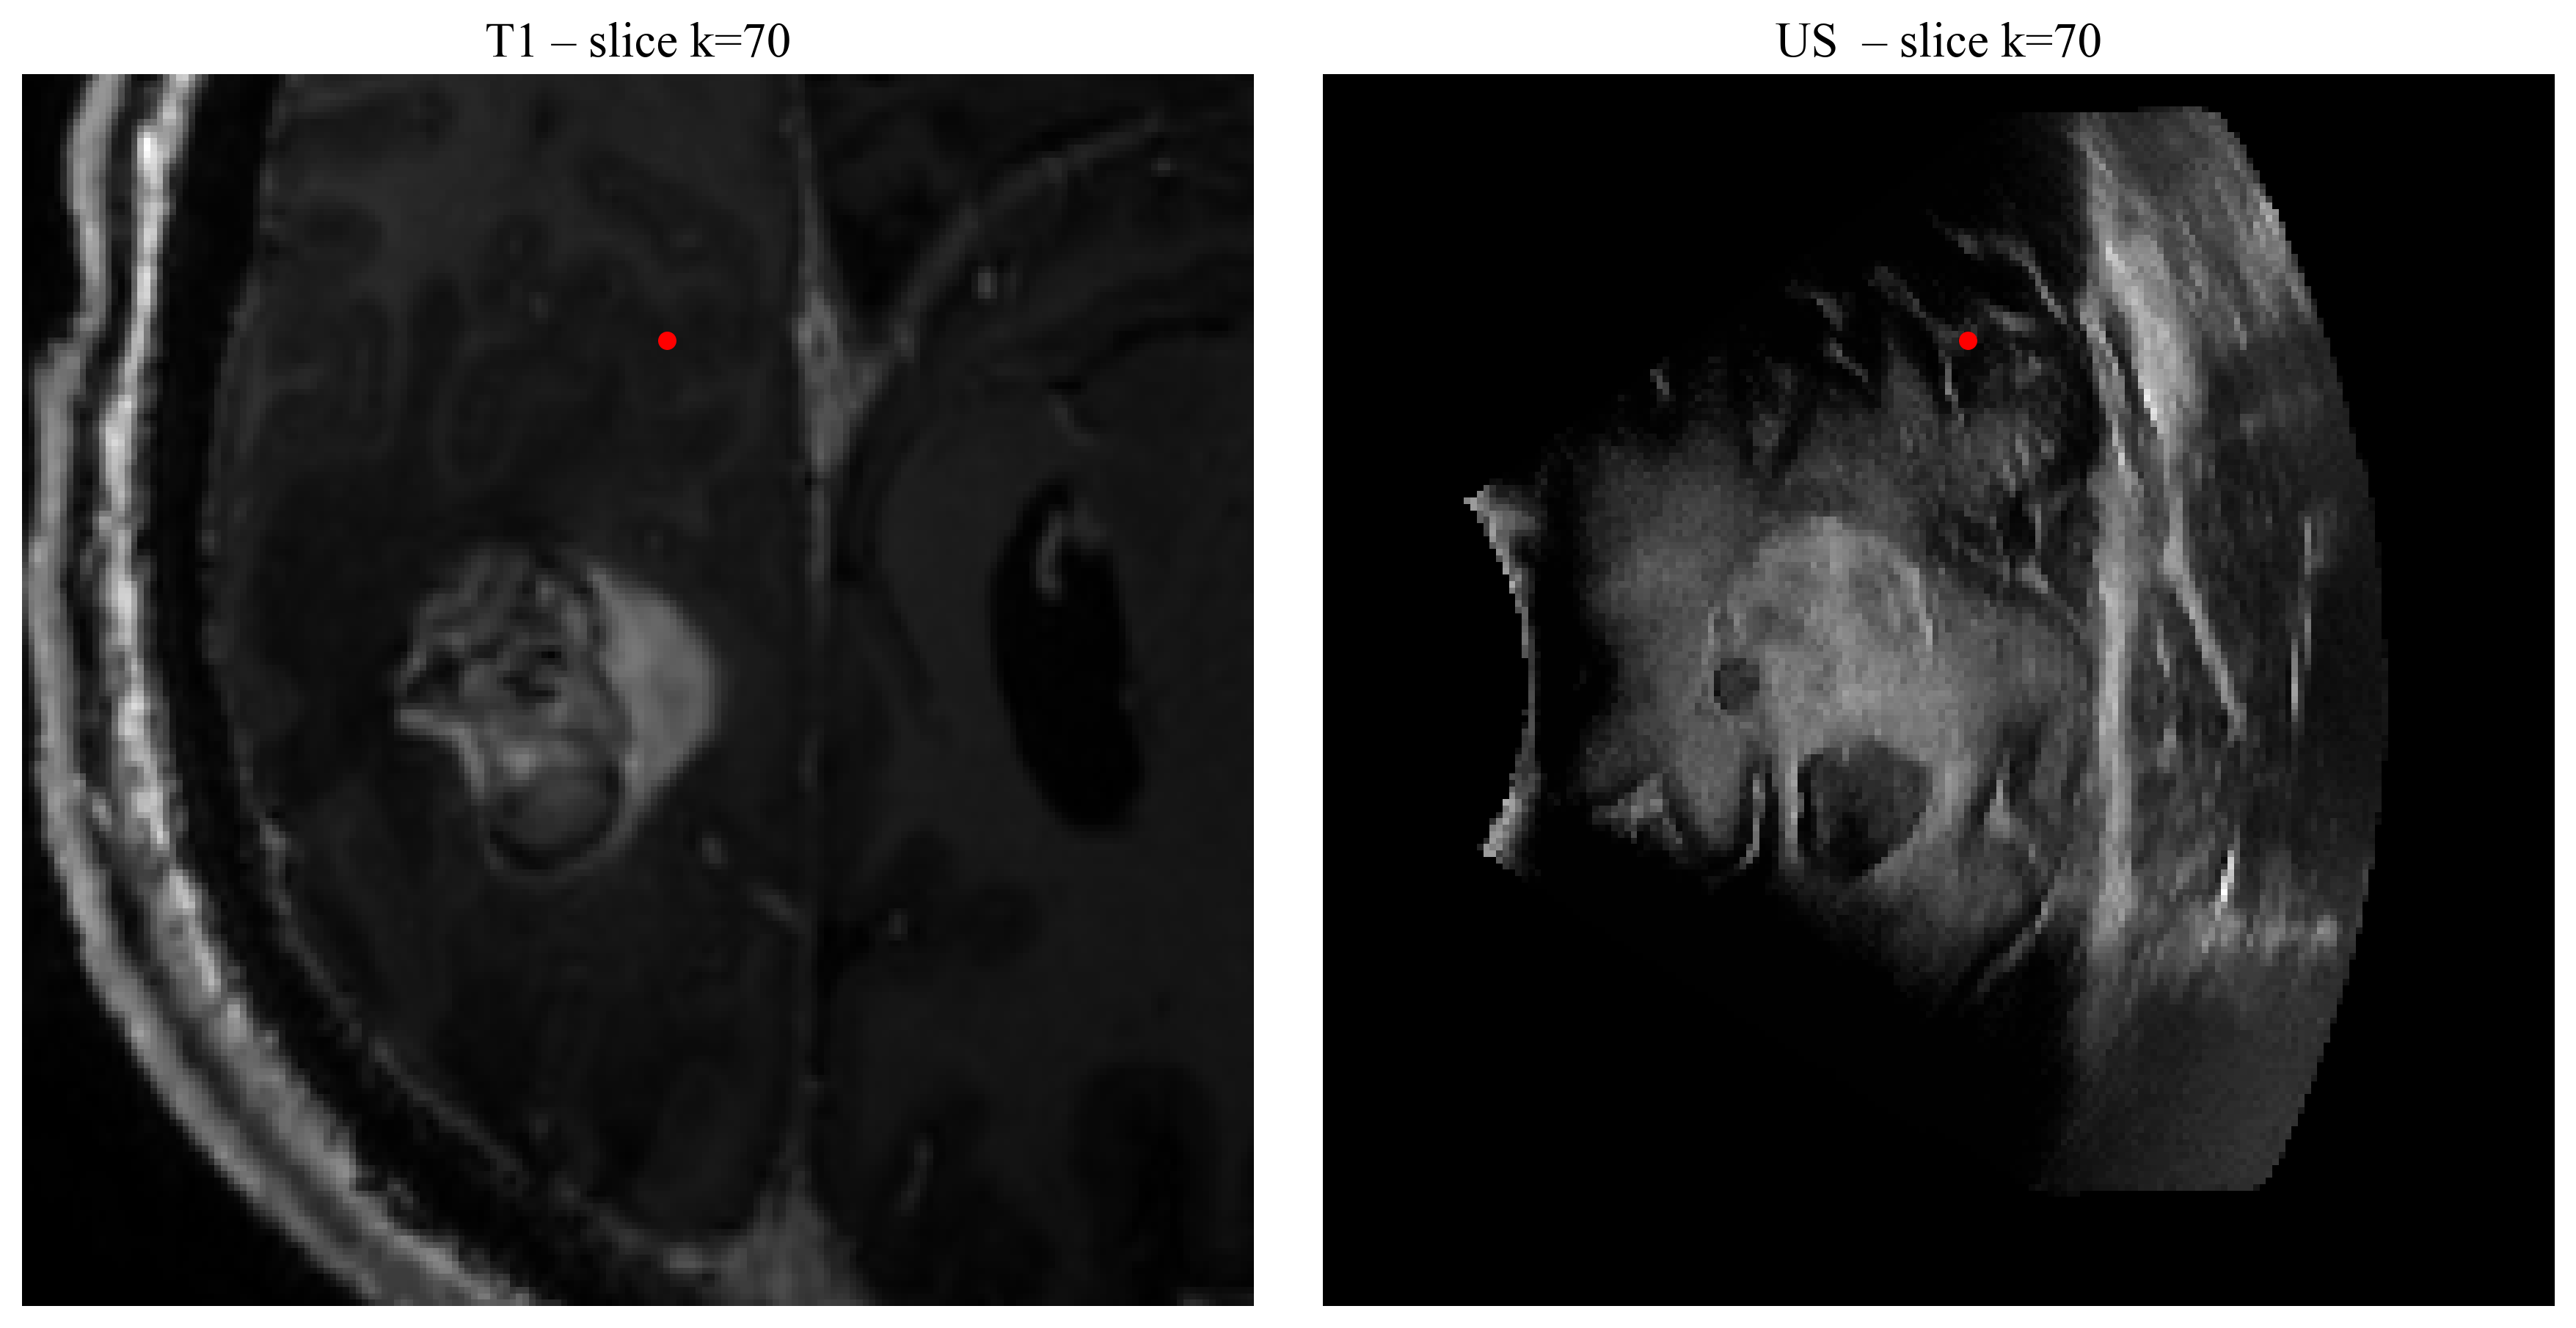

In [45]:
i_mri, j_mri, k_mri = 150, 100, 70 # Example indices for T1 MRI

us_slice, us_idx = mri_to_us_point(
    i_mri, 
    j_mri, 
    k_mri, 
    T1_vol, 
    T1_affine, 
    US_vol,
    US_affine) # this function aligns the two volumes for the given point

plot_mri_us_aligned(i_mri, 
                    j_mri, 
                    k_mri, 
                    T1_vol, 
                    us_slice, 
                    us_idx) # let's visualize the aligned slices

Next, we need to identify the edges of the US slice in order to select its orientation

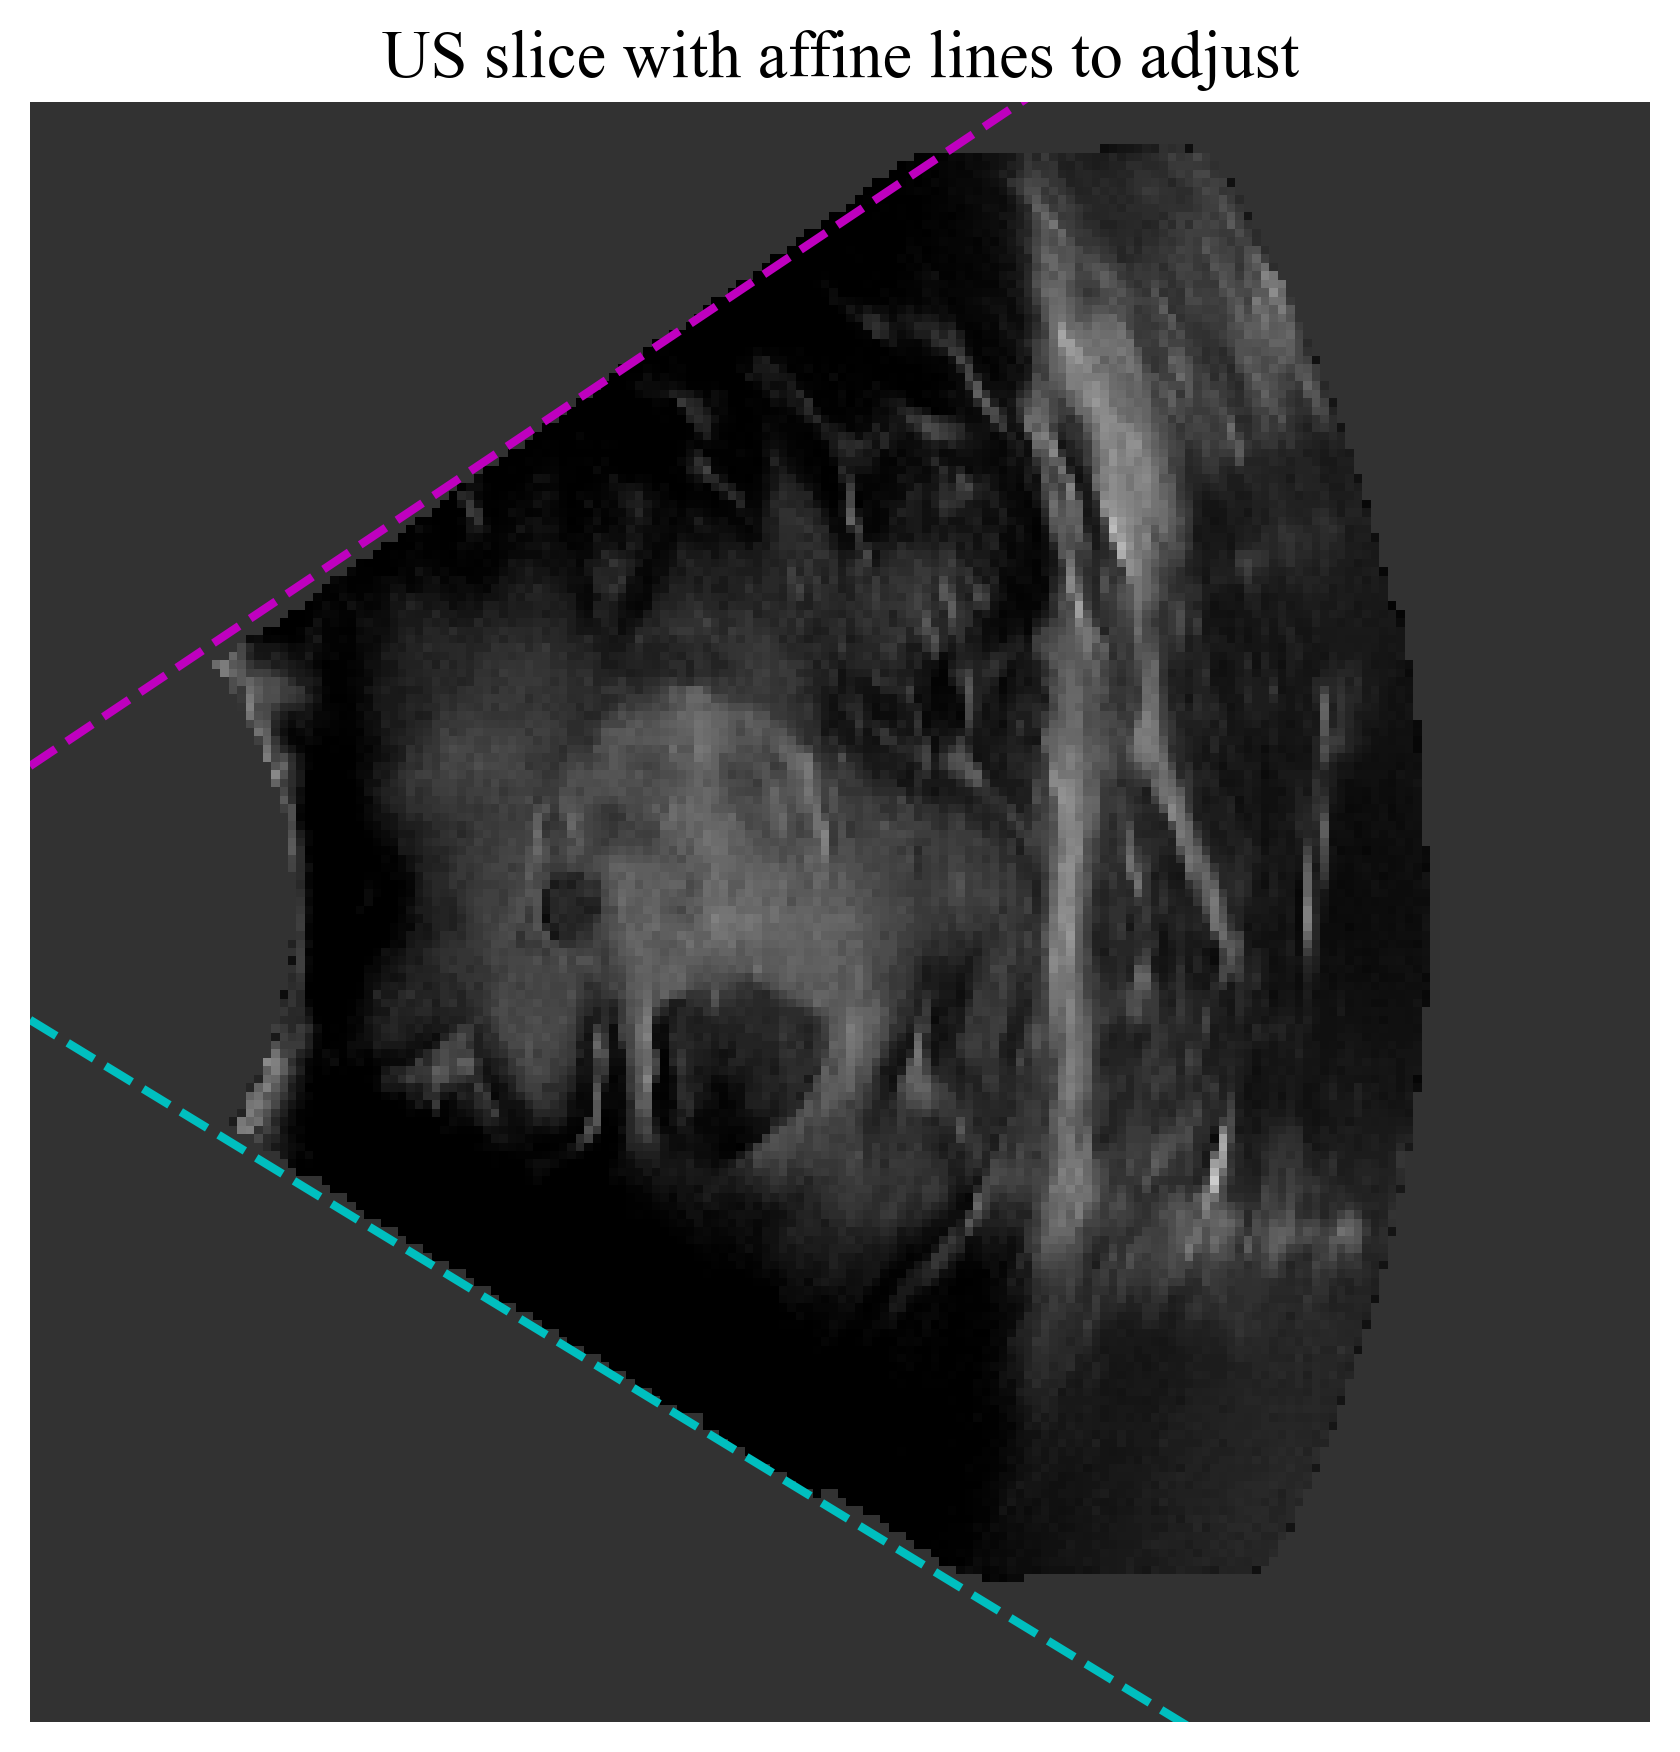

In [46]:
mL, bL = -0.61, 83  # Left edge line parameters (slope, intercept)
mR, bR = 0.67, 113  # Right edge line parameters (slope, intercept)

plot_us_with_affine_lines(us_slice, mL, bL, mR, bR) 

i_us, j_us, k_us = us_idx
H_us, W_us = us_slice.shape

Now that we're satisfied with the alignment, we need to identify at which depth the ray tracing needs to start.

In [47]:
cone_params = compute_us_apex_and_direction(mL, bL, mR, bR)
x0, y0 = cone_params["apex"]
opening_angle   = cone_params["opening_angle"]
direction_vec   = cone_params["direction_vector"][::-1]


(-23.4375, 97.296875) [ 0.99977352 -0.02128176] (np.float64(32.54981699133623), np.float64(96.10509645025455)) (np.float64(165.51969484575977), np.float64(93.27462239460908))
[-23.4375    97.296875  70.      ] [ 0.99977352 -0.02128176]


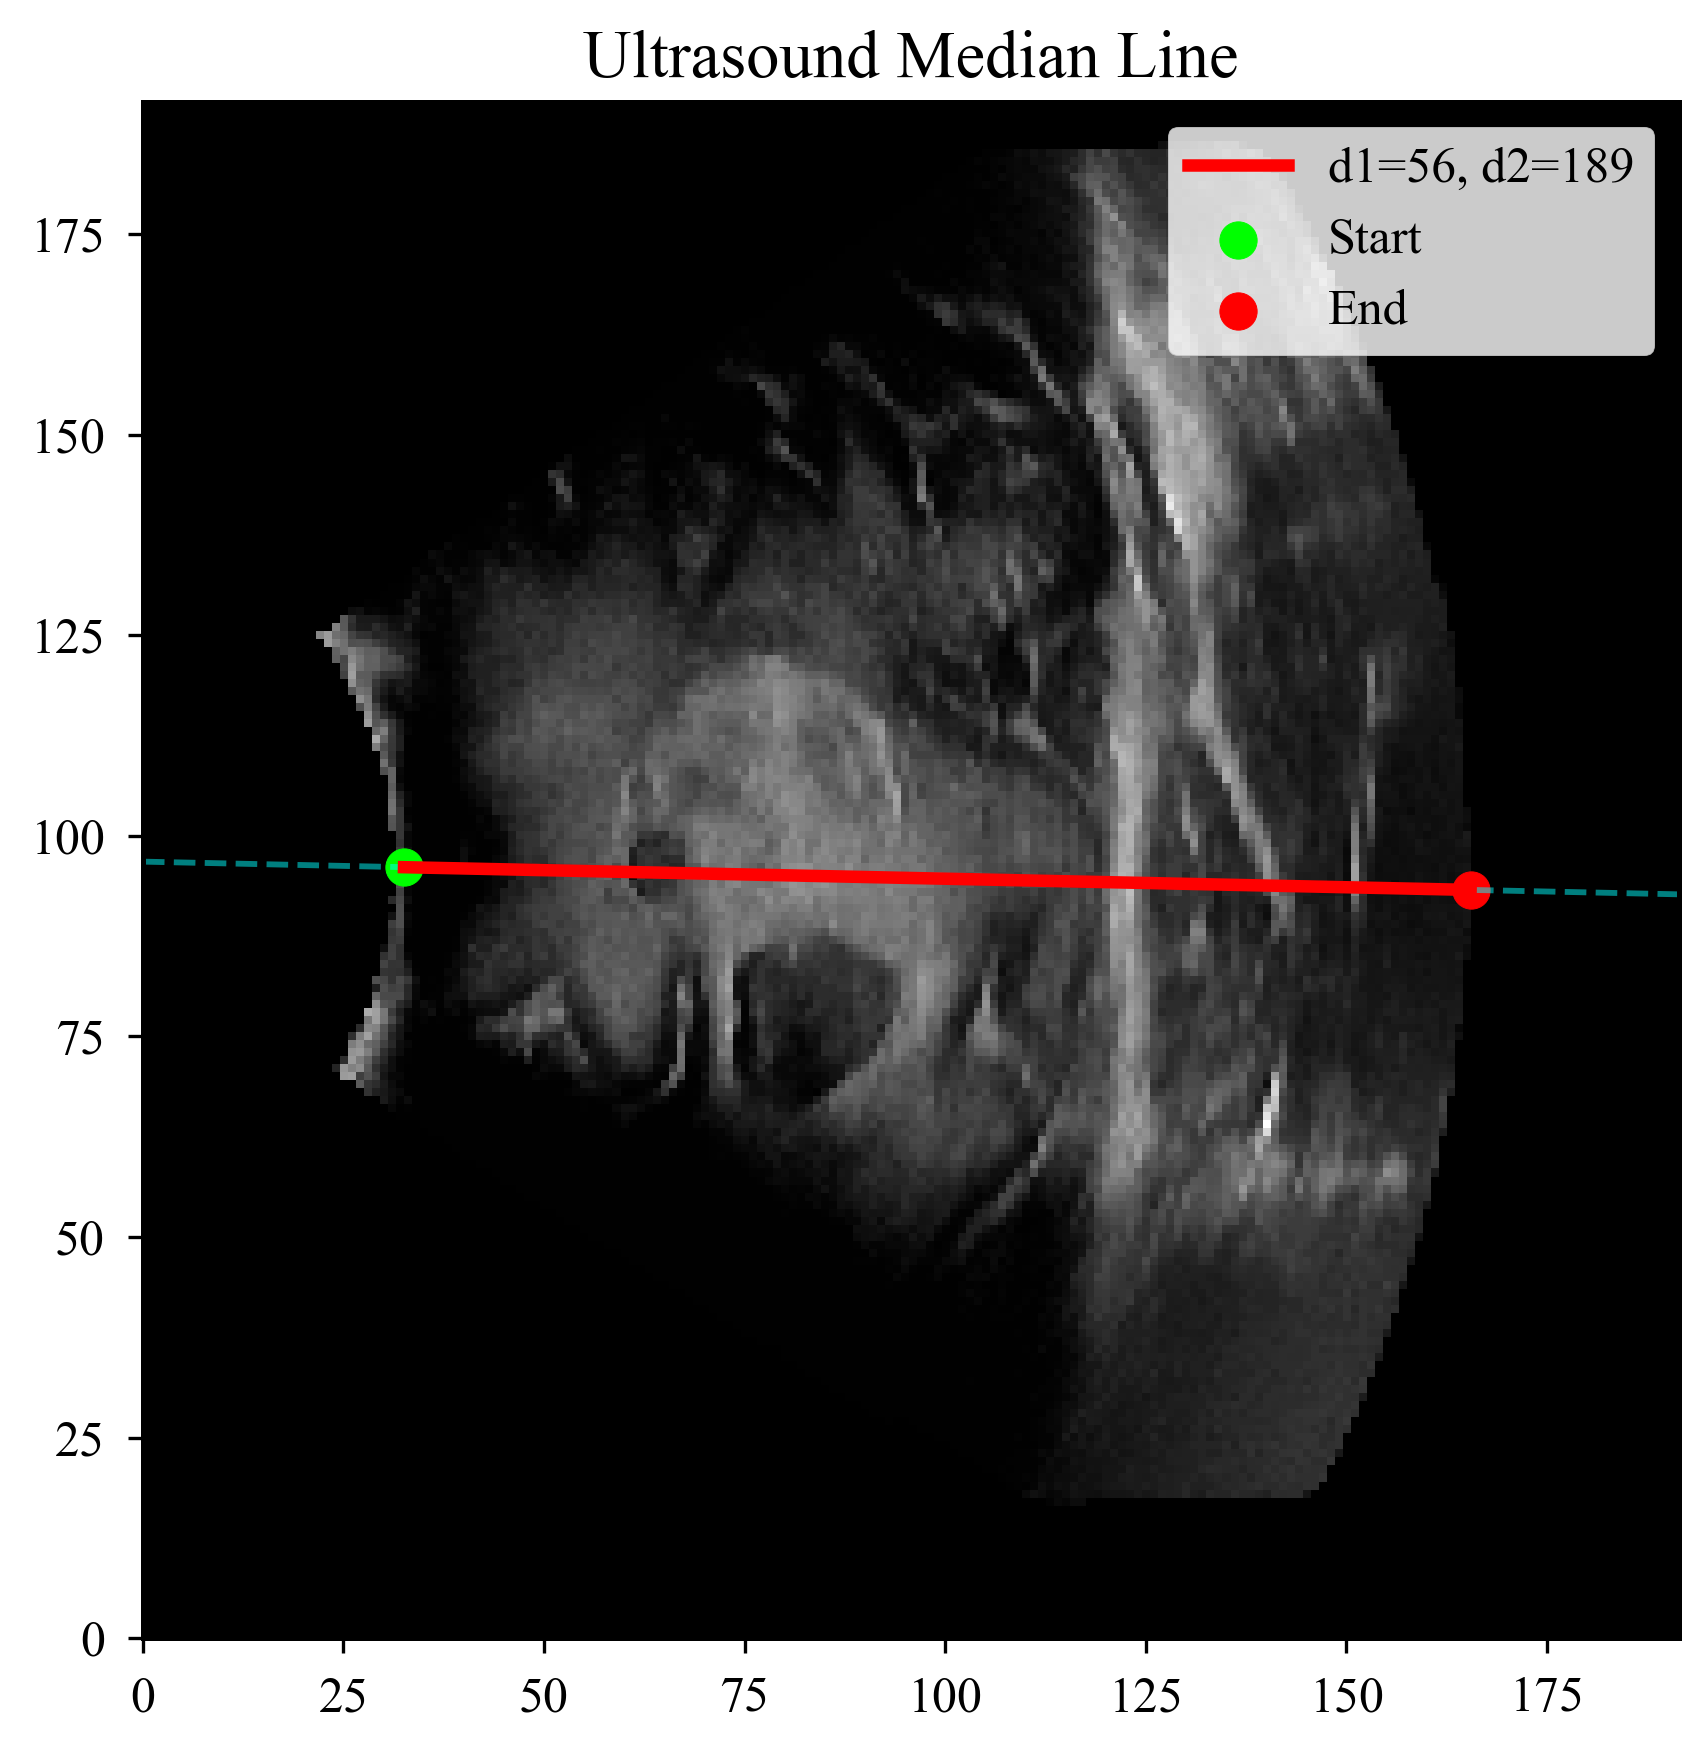

In [48]:
# Correct orientation for overlay_cone and direction vectors
# For US, ensure apex and direction are in (row, col) = (y, x) order
d1, d2 = plot_median_line(
    us_slice,
    cone_params["apex"],  # (x0, y0)
    direction_vec,
)

t1_slice = T1_vol[:, :, k_mri]
apex_us_vox = np.array([x0, y0, k_us])  # (x, y, z) in voxel space

# Convert apex and direction to MRI world coordinates
apex_mri_world, direction_mri_world = cone_us_to_mri_world(
    apex_us_vox,
    direction_vec,
    US_affine,
    T1_affine
)
print(apex_mri_world, direction_mri_world)
# For MRI, apex and direction are in (row, col) = (y, x) order

# Trace Rays!

We can finally trace the rays through the MRI volume and compute the acoustic impedance at each depth

C:\Users\noe\AppData\Local\Temp\ipykernel_30708\1209673500.py:12: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



[INFO] Visualizing sampled points in 3D volume
[INFO] Variances: x=947.4326, y=2511.1035, z=0.0000
(1, 1, 192, 156)


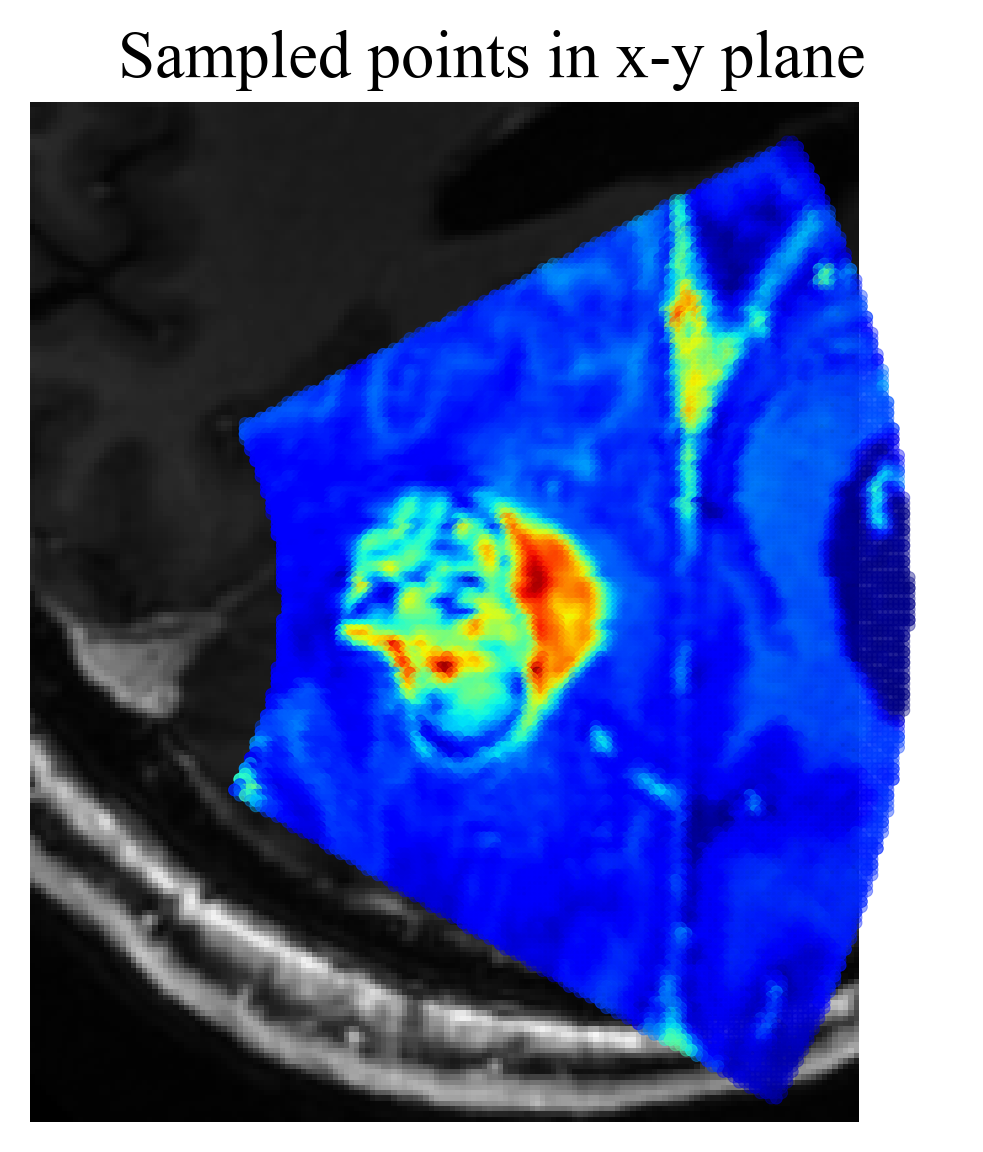

tensor(0.) tensor(1.1187)


In [55]:
H,W = us_slice.shape
renderer = UltrasoundRenderer(num_samples=d2, attenuation_coeff=0.0001)


# Geometric parameters for the cone segment
n_rays = 256
source = torch.tensor(apex_mri_world)
directions = generate_cone_directions(direction_mri_world[::-1], opening_angle/2, n_rays)

# Simulation
x,y,z, intensities = renderer.render_us_frame(
            volume=torch.tensor(Z_vol),
            source=source[[1,0,2]],
            directions=directions,
            angle=np.degrees(opening_angle)/2-5,
            plot=True,
            artifacts=True,
            start=d1,  # Adjusted start to match the cone segment,
            str_radial = 0.02,
            std_local = 0.2,

        )
output = differentiable_splat(x, 
                     y,
                     z, 
                     intensities, 
                     H=H, 
                     W=W, 
                     sigma=0.8)
print(output.min(), output.max())

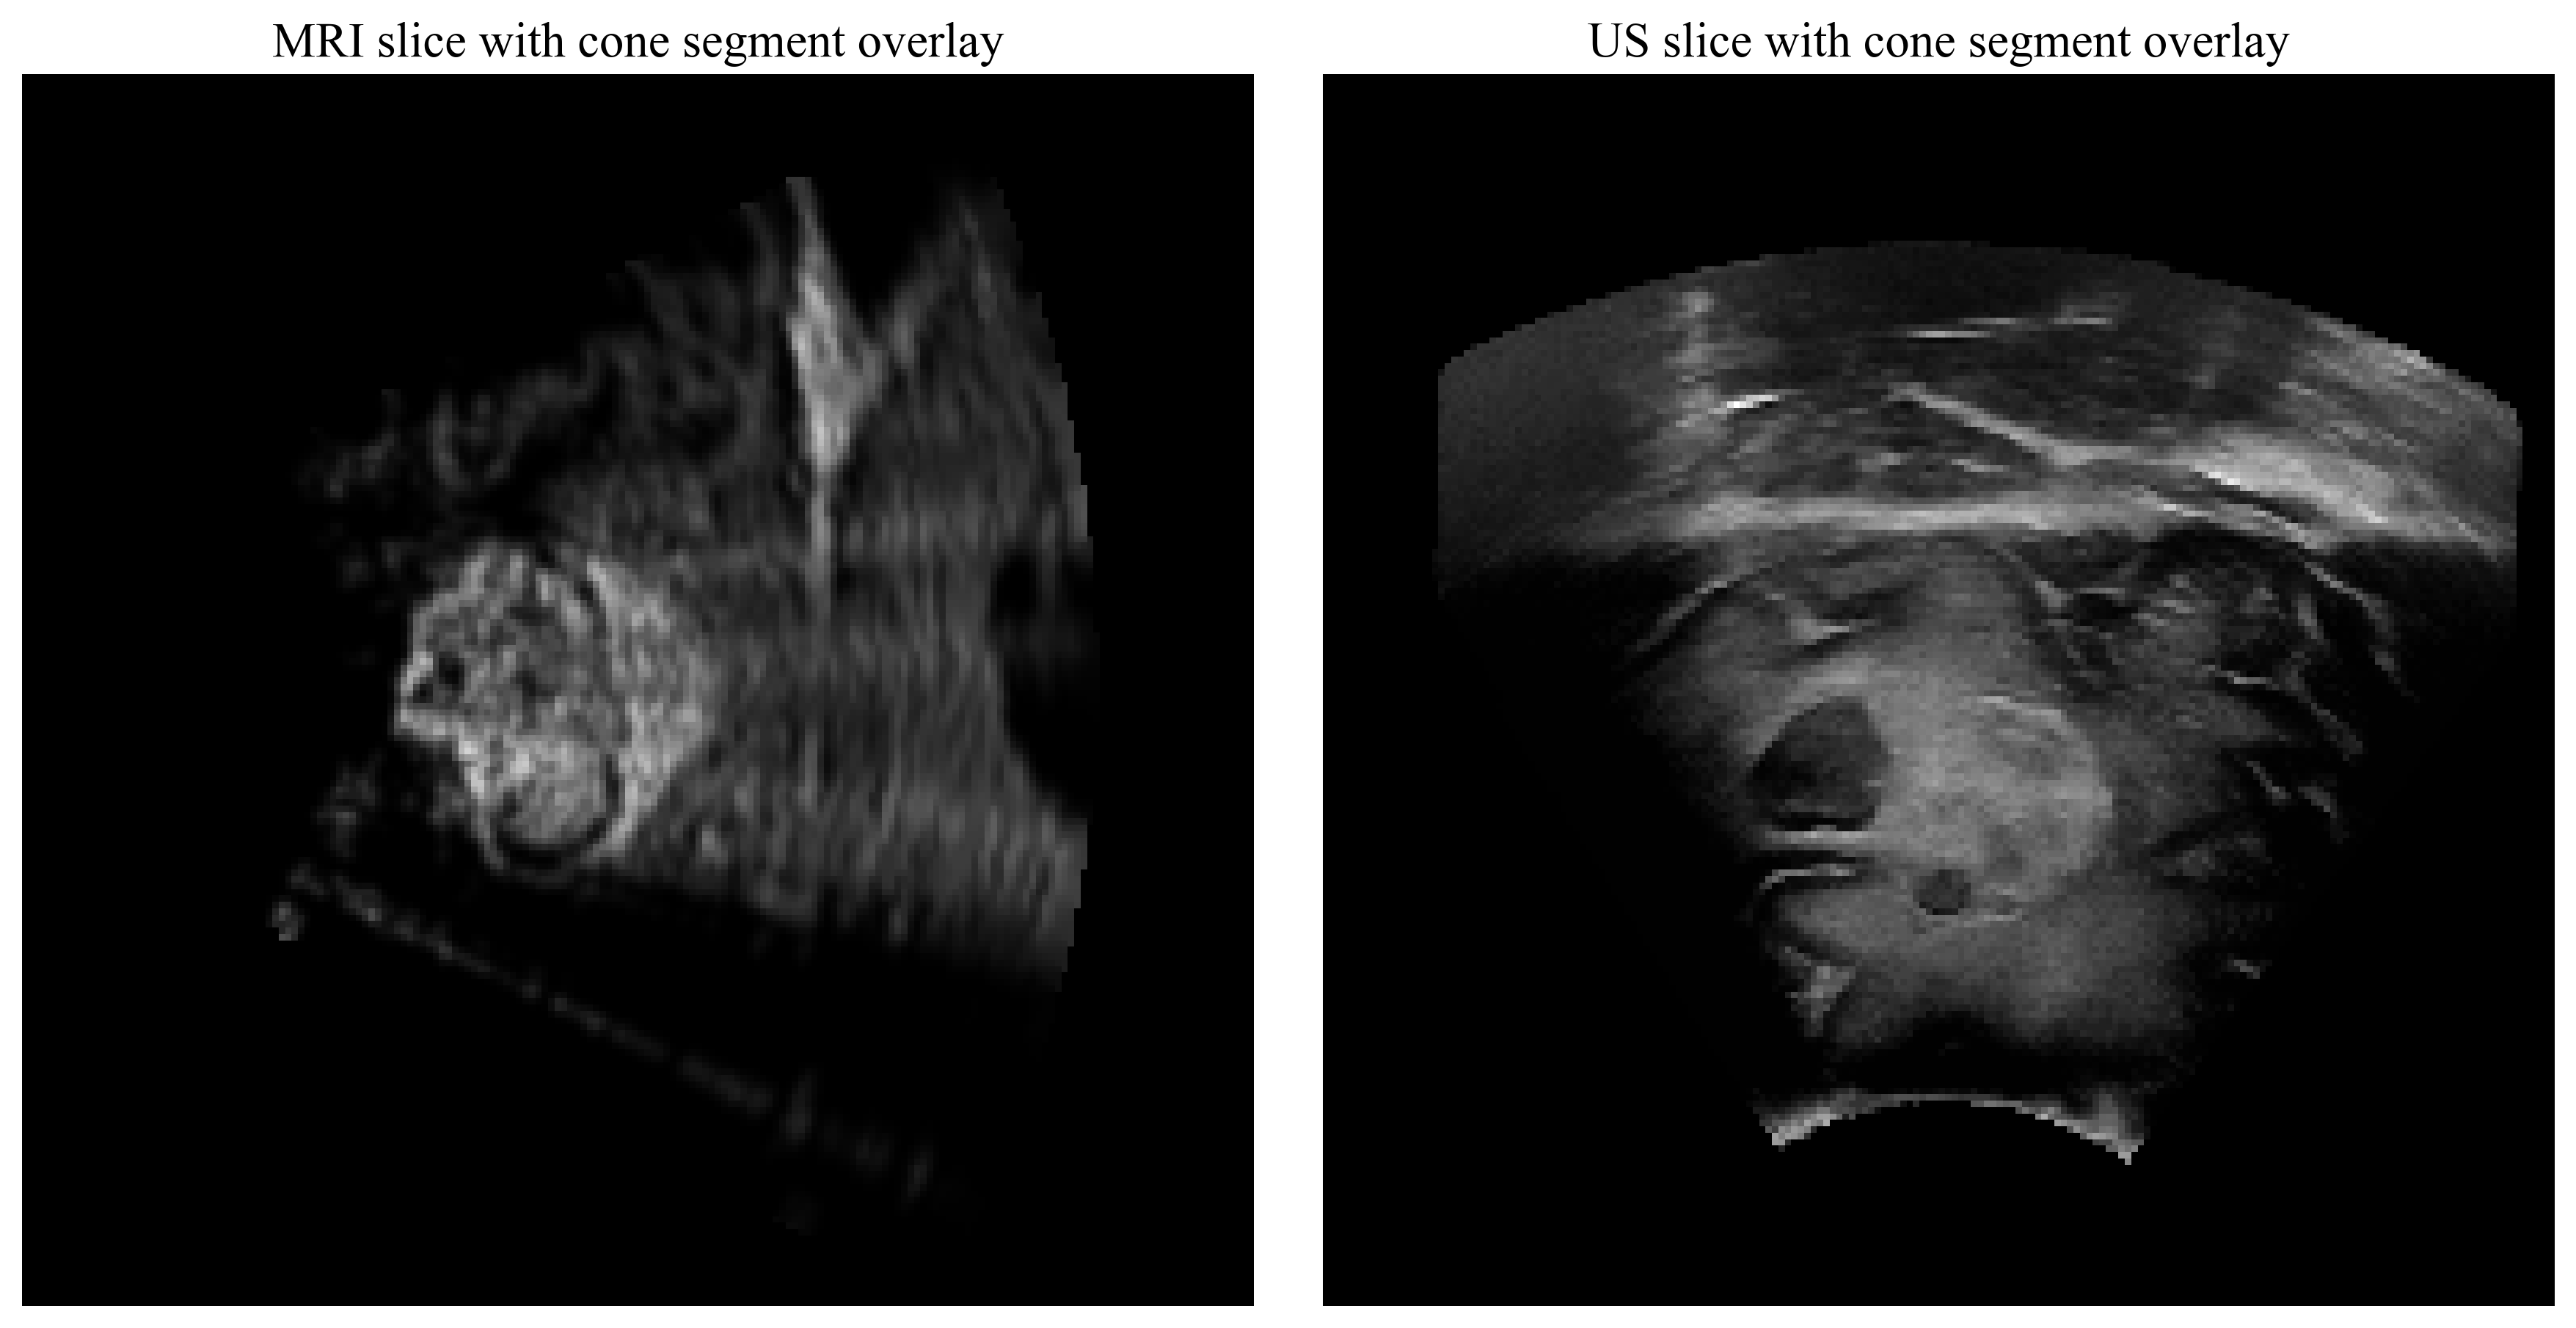

In [53]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(output, cmap='gray', origin='lower', vmin=0, vmax=1.4)
axs[0].set_title("MRI slice with cone segment overlay")
axs[0].axis('off')
axs[1].imshow(us_slice.T, cmap='gray', origin='lower')
axs[1].set_title("US slice with cone segment overlay")
axs[1].axis('off')
plt.tight_layout()
plt.show()

C:\Users\noe\AppData\Local\Temp\ipykernel_30708\3976785391.py:12: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



[INFO] Visualizing sampled points in 3D volume
[INFO] Variances: x=947.4326, y=2511.1035, z=0.0000
(1, 1, 192, 156)


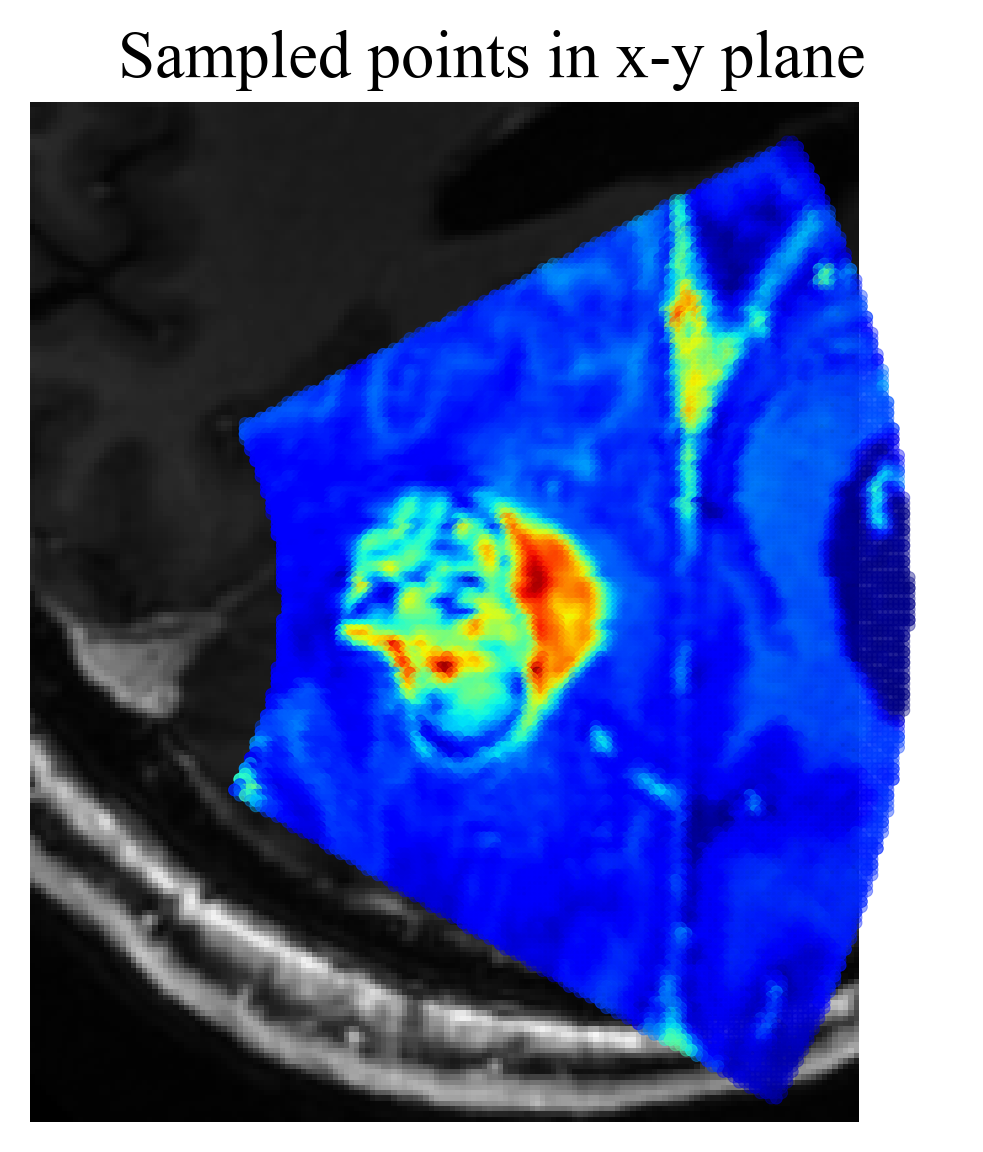

tensor(0.) tensor(1.1068)


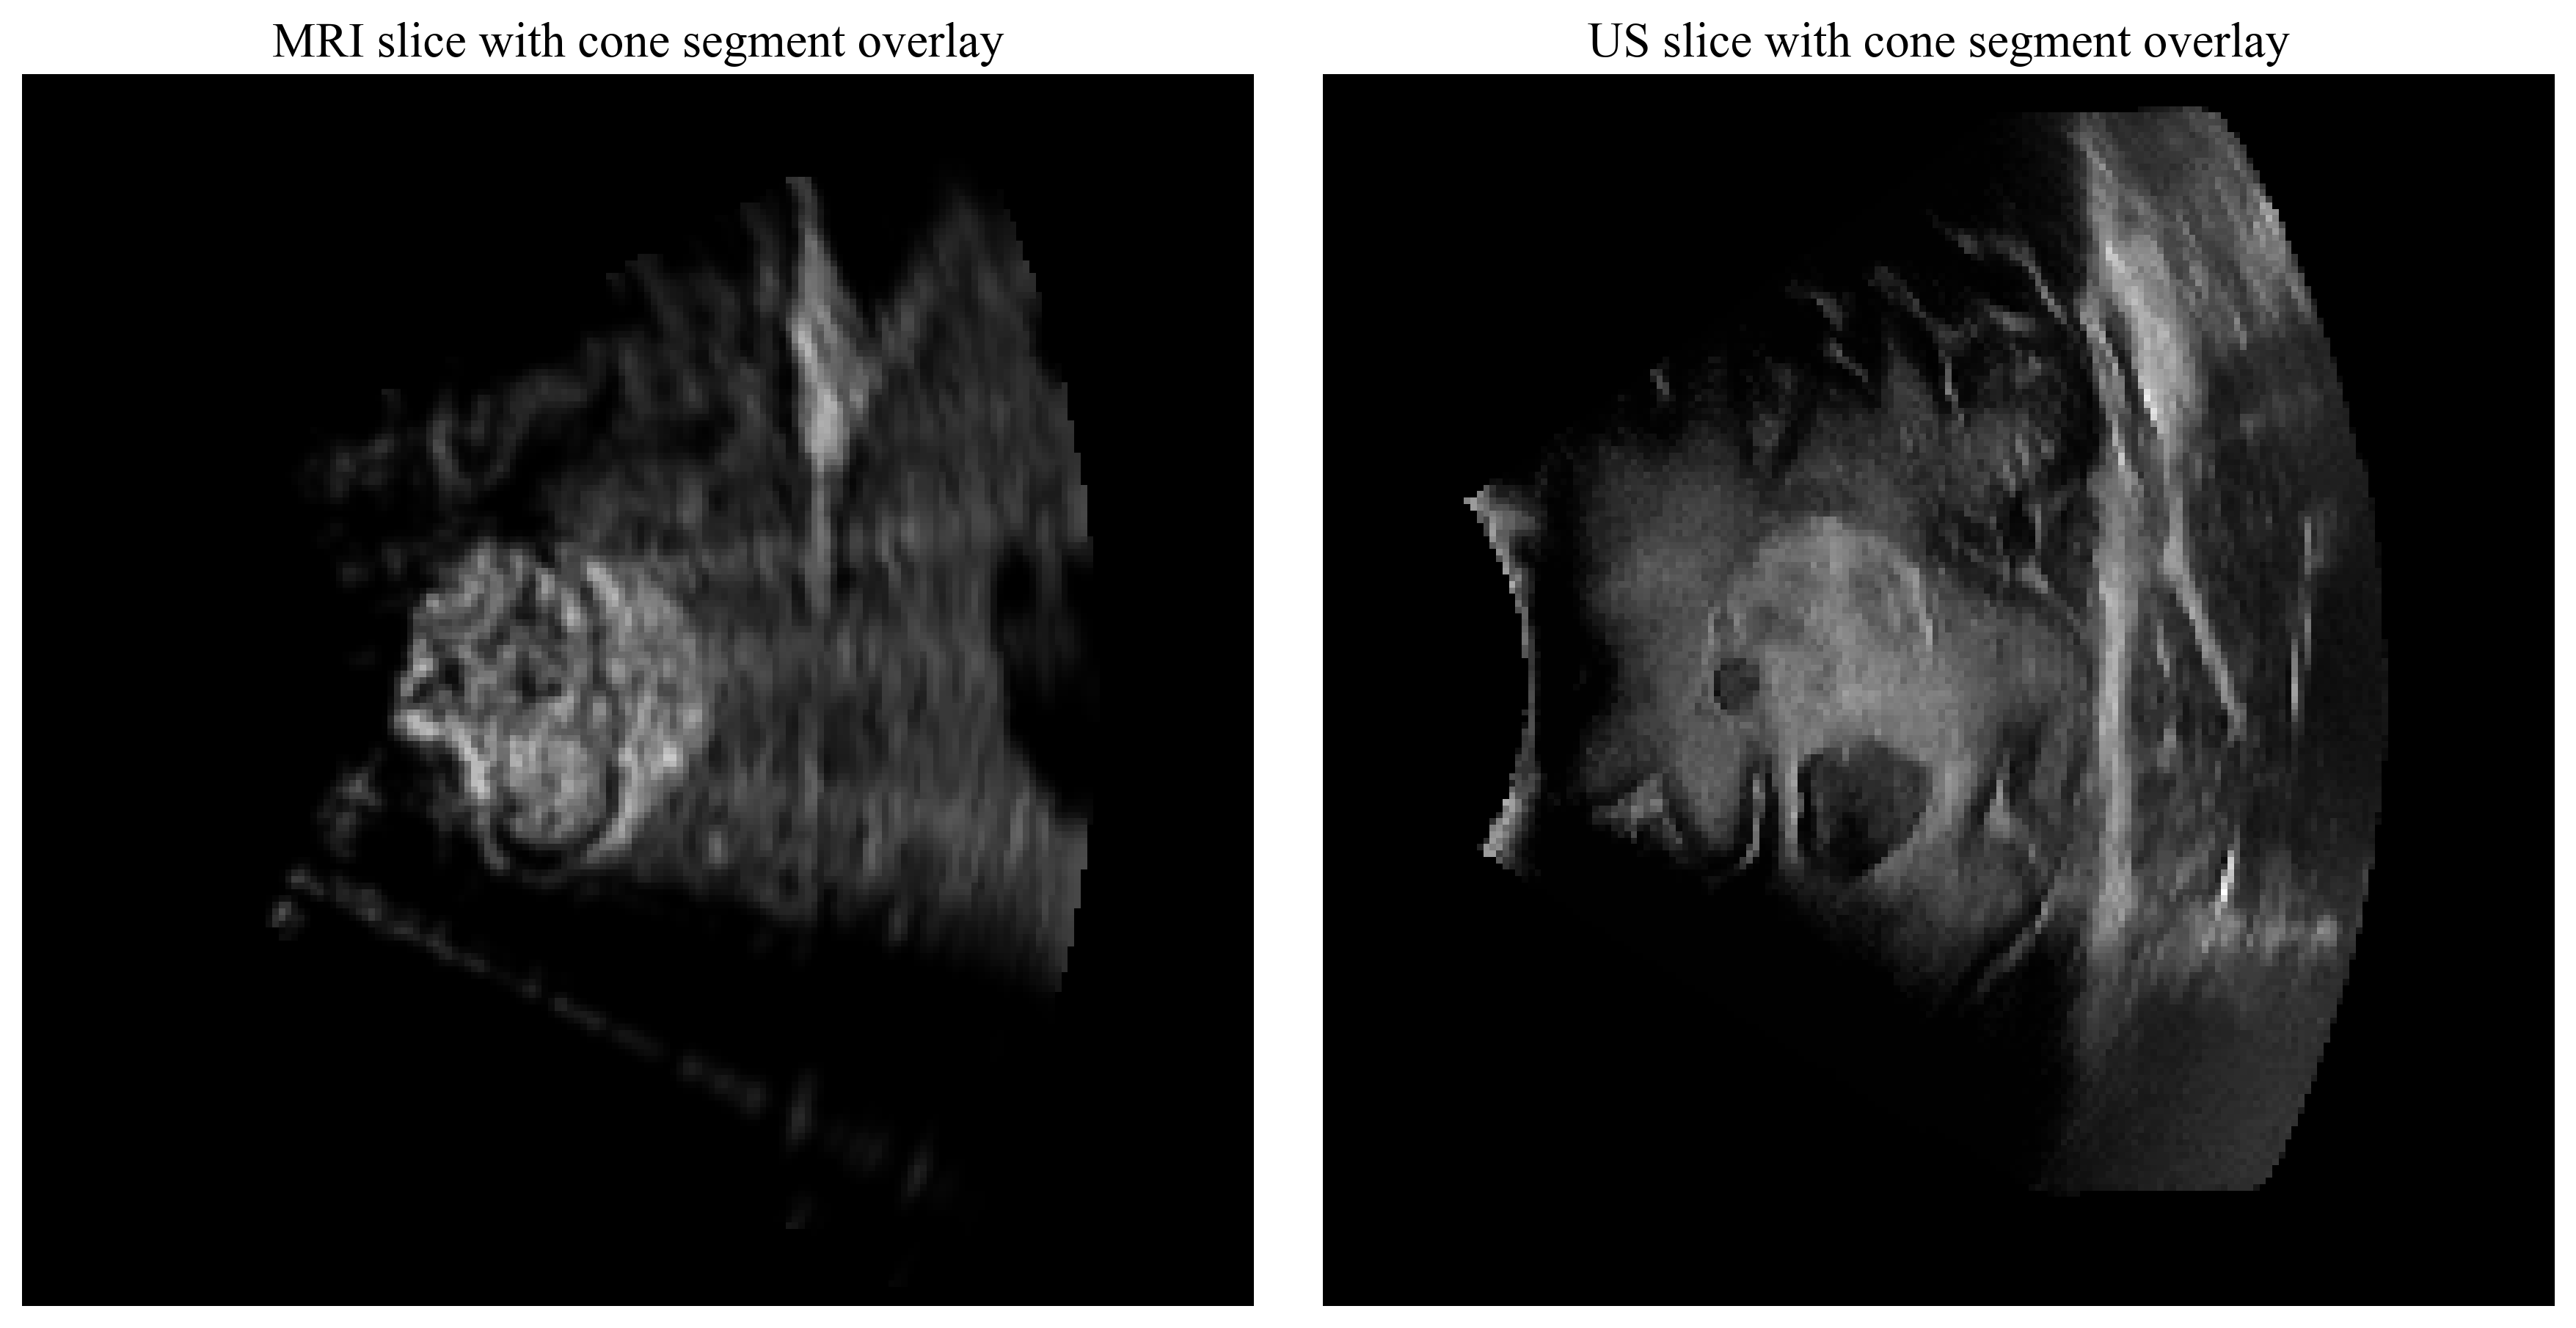

In [50]:
H,W = us_slice.shape
renderer = UltrasoundRenderer(num_samples=d2, attenuation_coeff=0.0001)


# Geometric parameters for the cone segment
n_rays = 256
source = torch.tensor(apex_mri_world)
directions = generate_cone_directions(direction_mri_world[::-1], opening_angle/2, n_rays)

# Simulation
x,y,z, intensities = renderer.render_us_frame(
            volume=torch.tensor(Z_vol),
            source=source[[1,0,2]],
            directions=directions,
            angle=np.degrees(opening_angle)/2-5,
            plot=True,
            artifacts=True,
            start=d1,  # Adjusted start to match the cone segment,
            str_radial = 0.02,
            std_local = 0.2,

        )
output = differentiable_splat(x, 
                     y,
                     z, 
                     intensities, 
                     H=H, 
                     W=W, 
                     sigma=0.8)
print(output.min(), output.max())
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(output, cmap='gray', origin='lower', vmin=0, vmax=1.4)
axs[0].set_title("MRI slice with cone segment overlay")
axs[0].axis('off')
axs[1].imshow(us_slice, cmap='gray', origin='lower')
axs[1].set_title("US slice with cone segment overlay")
axs[1].axis('off')
plt.tight_layout()
plt.show()